<h2 style = "color:green">INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The Indian technology job market is evolving rapidly, driven by growing demand for data, artificial intelligence, cloud computing, and software development professionals. This dataset provides a comprehensive view of the Indian tech hiring landscape in 2025, containing 23,201 real job listings collected from Naukri.com across major Indian cities and remote locations. It includes information on job roles, salary ranges, required skills, experience levels, work modes, company characteristics, and skill domains. Through Exploratory Data Analysis (EDA), this project aims to uncover hiring trends, salary patterns, skill demands, and geographical differences across various technology roles, providing valuable insights for job seekers, recruiters, and industry professionals.

<h2 style = "color:green">OBJECTIVES:


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>

<li>Analyze the distribution of tech job opportunities across different roles and cities.</li>
<li>Explore salary trends and identify factors influencing compensation.</li>
<li>Examine the demand for various technical skills and skill domains.
<li>Compare hiring patterns across Remote, Hybrid, and On-site work modes.
<li>Investigate experience-level requirements and opportunities for freshers and senior professionals.
<li>Identify cities and roles with the highest concentration of job openings.
<li>Generate actionable insights into the Indian tech job market to support career planning and workforce analysis.

</ul>
</div>

<h3 style = "color:green">1. Getting Ready with Data

In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [2]:
data = pl.read_csv('/home/kartika/Datasets/indian_tech_jobs_2026.csv')
data = data.to_pandas()


In [3]:
data.head()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
0,1,Data Scientist,Cisco,4.1,Bengaluru,Bangalore,Data Scientist,7-10 Yrs,7.0,10.0,...,2025-06-10,Undisclosed,Senior (6-8 Yrs),False,Bangalore,Business Intelligence,0.0,21.0,False,False
1,2,Data Scientist,Caterpillar Inc,4.1,Bengaluru,Bangalore,Data Scientist,4-8 Yrs,4.0,8.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Bangalore,AI/ML/DL,0.0,21.0,False,False
2,3,Analytics Data Scientist,Foreign IT Consulting MNC,3.6,"Hyderabad, Chennai, Bengaluru",Bangalore,Data Scientist,4-9 Yrs,4.0,9.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Business Intelligence,0.0,21.0,False,False
3,4,Data Scientist,Fortune 500 IT Services Company,3.6,"Mumbai, Bengaluru",Bangalore,Data Scientist,10-14 Yrs,0.0,0.0,...,2025-06-10,Undisclosed,Fresher,False,Mumbai,Data Science,0.0,21.0,True,False
4,5,Sr. Artificial Intelligence Engineer,Fortune 500 Product-based MNC,3.6,"Pune, Bengaluru",Bangalore,Data Scientist,5-10 Yrs,5.0,10.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),True,Pune,Data Science,0.0,21.0,False,False


In [4]:
data.tail()

,job_id,job_title,company_name,company_rating,location,scraped_city,role_category,experience_raw,experience_min_yrs,experience_max_yrs,...,scraped_at,salary_tier,experience_tier,is_senior,primary_city,skill_domain,salary_midpoint_lpa,days_since_posted,is_fresher_friendly,salary_negotiable
23196,23197,Python Developer-Hyderabad,Infosys,3.5,Hybrid - Hyderabad,Hyderabad,Python Developer,2-7 Yrs,2.0,7.0,...,2025-06-10,Undisclosed,Junior (0-2 Yrs),False,Hyderabad,Data Science,0.0,1.0,False,False
23197,23198,Python Developer,Accufy,3.6,Hyderabad,Hyderabad,Python Developer,0-4 Yrs,0.0,4.0,...,2025-06-10,Undisclosed,Fresher,False,Hyderabad,Data Science,0.0,1.0,True,False
23198,23199,Walk in Interview Python Developer II Hyderabad,Tata Consultancy Services,3.3,"Hyderabad, Pune, Mumbai (All Areas)",Hyderabad,Python Developer,13 Jun,13.0,8.0,...,2025-06-10,Undisclosed,Lead/Architect (9+ Yrs),False,Hyderabad,Data Engineering,0.0,21.0,False,False
23199,23200,Python Developer,Mediamint,2.8,Hybrid - Hyderabad,Hyderabad,Python Developer,3-5 Yrs,3.0,5.0,...,2025-06-10,Undisclosed,Mid (3-5 Yrs),False,Hyderabad,Data Science,0.0,0.0,False,False
23200,23201,Python Developer,CMM Level 5 IT Company,3.6,Hyderabad,Hyderabad,Python Developer,7-12 Yrs,7.0,12.0,...,2025-06-10,Senior (10-20 LPA),Senior (6-8 Yrs),False,Hyderabad,Data Science,13.0,1.0,False,False


In [5]:
data.drop(
    ['job_id', 'posted_date_raw', 'job_url',
      'data_source', 'scraped_at', 'salary_midpoint_lpa',
      'days_since_posted'], axis = 'columns', inplace = True
)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Dropped irrelevant columns.

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23201 entries, 0 to 23200
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            23201 non-null  object 
 1   company_name         23201 non-null  object 
 2   company_rating       23201 non-null  float64
 3   location             23201 non-null  object 
 4   scraped_city         23201 non-null  object 
 5   role_category        23201 non-null  object 
 6   experience_raw       23201 non-null  object 
 7   experience_min_yrs   23201 non-null  float64
 8   experience_max_yrs   23201 non-null  float64
 9   salary_raw           23201 non-null  object 
 10  salary_min_lpa       23201 non-null  float64
 11  salary_max_lpa       23201 non-null  float64
 12  salary_disclosed     23201 non-null  bool   
 13  skills_required      23201 non-null  object 
 14  skills_count         23201 non-null  int64  
 15  job_description      23201 non-null 

In [7]:
data.isnull().sum()

job_title              0
company_name           0
company_rating         0
location               0
scraped_city           0
role_category          0
experience_raw         0
experience_min_yrs     0
experience_max_yrs     0
salary_raw             0
salary_min_lpa         0
salary_max_lpa         0
salary_disclosed       0
skills_required        0
skills_count           0
job_description        0
work_mode              0
company_size_bucket    0
salary_tier            0
experience_tier        0
is_senior              0
primary_city           0
skill_domain           0
is_fresher_friendly    0
salary_negotiable      0
dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No null values.

In [8]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No duplicate values.

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2.1 Job Roles Distribution

In [10]:
data['role_category'].value_counts()

role_category
Data Scientist               6455
Data Analyst                 4729
Business Analyst             4505
Machine Learning Engineer    4004
Data Engineer                1922
Python Developer             1586
Name: count, dtype: int64

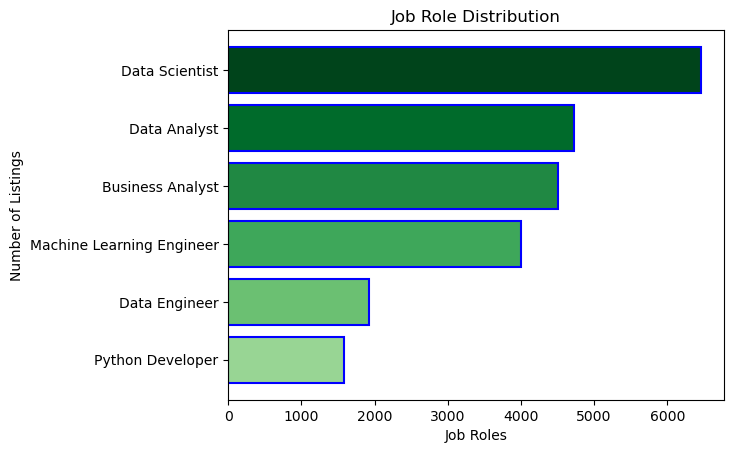

In [28]:
plt.barh(
    y = data['role_category'].value_counts().index,
    width = data['role_category'].value_counts().values,
    color = plt.cm.Greens(np.linspace(1,0.4,6)),
    linewidth = 1.5,
    edgecolor = 'blue',
)

plt.title("Job Role Distribution")
plt.xlabel('Job Roles')
plt.ylabel('Number of Listings')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listing covers six  data related tech jobs out of which Data Scientist role is most listed. Data Analyst and Business Analyst have nearly same number of listings, followed by ML Engineer. Data Engineer and Python Developer have least number of listings.

<div>

<h3 style = "color:green">2.2 Cities Distribution

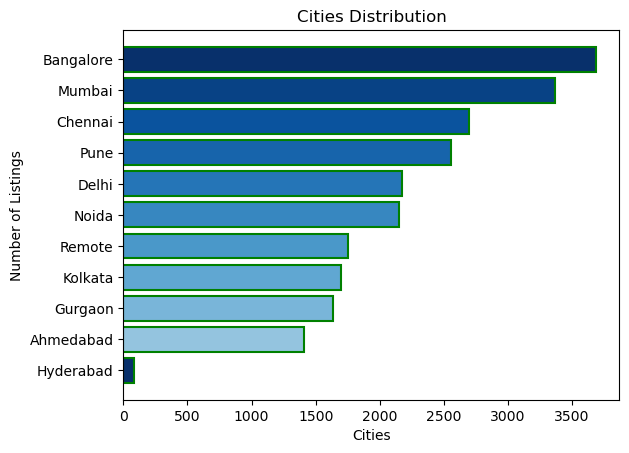

In [30]:
plt.barh(
    y = data['scraped_city'].value_counts().index,
    width = data['scraped_city'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1,0.4,10)),
    linewidth = 1.5,
    edgecolor = 'green',
)

plt.title("Cities Distribution")
plt.xlabel('Cities')
plt.ylabel('Number of Listings')
plt.gca().invert_yaxis()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The job listings are from around ten different cities, out of which Bangalore has the most listing followed by Mumbai. Chennai and Pune have same number of listings, similary Delhi and Noida have same number of listing.

<div>

<h3 style = "color:green">2.3